In [1]:
from engine_api.math_service.math_model.tsp_runner import KCycleTSPRunner
from engine_api.math_service.math_model.tsp_config import *

In [2]:
runner = KCycleTSPRunner()

runner.load_data(
    DATA_SOURCE=DATA_SOURCE,
    EXCEL_PATH=EXCEL_PATH,
    TSPLIB_PATH=TSPLIB_PATH,
    s_value=s_value,
    k_value=k_value
)

runner.build_model(
    CONNECTIVITY=CONNECTIVITY,
    group_size=group_size,
    speed_kmph=speed_kmph,
    route_pace=route_pace,
    fuel_consumption=fuel_cons,
    fuel_price=fuel_price,
    use_osrm=True
)

🌐 Connecting to OSRM (Public API)...
🌍 OSRM Request (10 pts): http://router.project-osrm.org/table/v1/driving/22...
✅ OSRM data received.
✅ Using OSRM real-world data.


In [5]:
import math

# Візьмемо дві точки з твого туру, наприклад 1 -> 4
# (Переконайся, що ці ID існують у тебе)
id_from = 1
id_to = 2

if (id_from, id_to) in runner.d_data:
    # 1. Відстань, яку використовує модель (OSRM?)
    model_dist = runner.d_data[(id_from, id_to)]

    # 2. Відстань по прямій (Haversine formula - груба)
    lat1, lon1 = runner.df.loc[runner.df['id'] == id_from, ['lat', 'lon']].values[0]
    lat2, lon2 = runner.df.loc[runner.df['id'] == id_to, ['lat', 'lon']].values[0]

    R = 6371  # радіус Землі км
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = math.sin(dlat/2)**2 + math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) * math.sin(dlon/2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    euclid_dist = R * c

    print(f"📍 Перевірка відрізка {id_from} -> {id_to}:")
    print(f"   📏 По прямій (Euclid): {euclid_dist:.2f} км")
    print(f"   🚗 У моделі (OSRM?):   {model_dist:.2f} км")

    if model_dist > euclid_dist * 1.05:
        print("\n✅ Ура! Дистанція суттєво більша за пряму. Це OSRM.")
    elif model_dist == round(euclid_dist, 2):
        print("\n⚠️ Увага! Дистанції ідентичні. OSRM не спрацював, це математика.")
    else:
        print("\n🤔 Дивно. Різниця мала. Можливо, дорога дуже пряма?")
else:
    print("Такого ребра немає в матриці.")

📍 Перевірка відрізка 1 -> 2:
   📏 По прямій (Euclid): 58.22 км
   🚗 У моделі (OSRM?):   109.72 км

✅ Ура! Дистанція суттєво більша за пряму. Це OSRM.


WARNING (W1002): Setting Var 'u[1]' to a numeric value `0` outside the bounds
(1, 5).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002

Problem: 
- Lower bound: -.inf
  Upper bound: .inf
  Number of objectives: 1
  Number of constraints: 0
  Number of variables: 199
  Sense: unknown
Solver: 
- Status: ok
  Message: CPLEX 22.1.2\x3a optimal solution; objective 86.79; 426 simplex iterations
  Termination condition: optimal
  Id: 0
Solution: 
- number of solutions: 0
  number of solutions displayed: 0

Objective = 86.78999999999999
Total distance = 86.78999999999999 km
Total budget   = 12845.74325 UAH
  - Locations: 12440.00 UAH
  - Fuel:      405.74 UAH
Total time     = 554.148 minutes
Tour: [1, 4, 7, 3, 5, 6, 1]


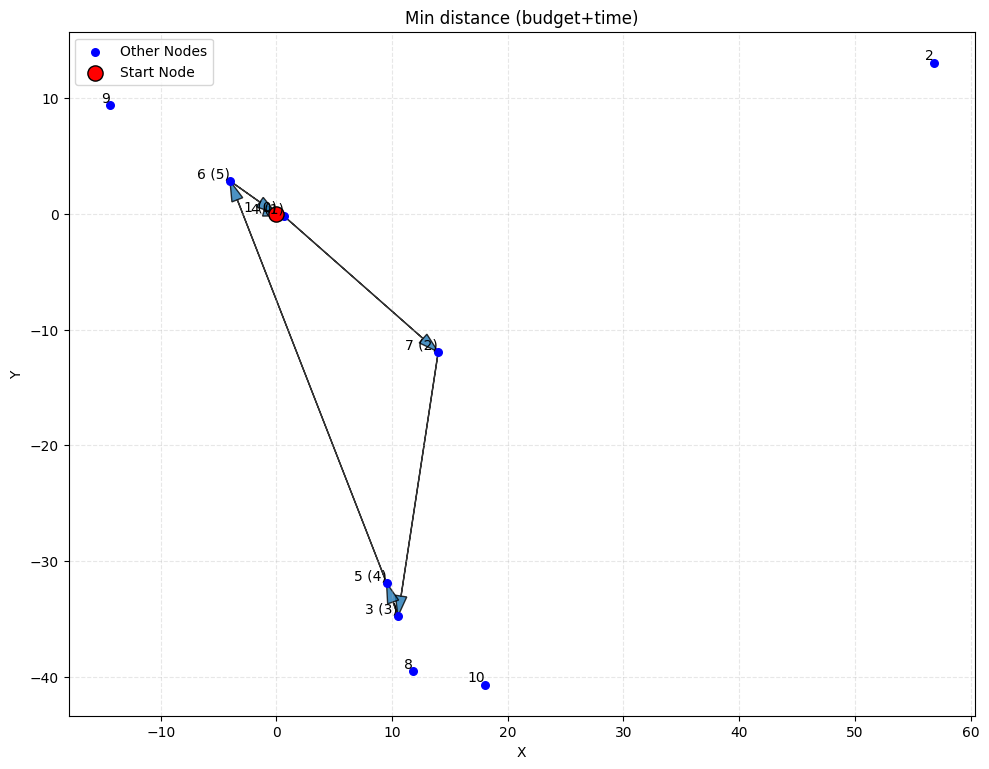

In [3]:
runner.apply_min_distance(budget_max=budget_max, time_max=time_max)

results, ok = runner.solve(SOLVER=SOLVER, NEOS_EMAIL=NEOS_EMAIL, tee=False)

if ok:
    runner.print_metrics()
    runner.extract_tour()
    print("Tour:", runner.tour)
    runner.plot(title="Min distance (budget+time)")
else:
    print("Cannot construct tour with provided constraints")
    print(f"Check your limits:\n - Budget: {budget_max} UAH\n - Time: {time_max:.1f} Hours\n - Number of places: {k_value}")
    print("Try increasing your budget/time or reducing the number of points.")

WARNING (W1002): Setting Var 'u[1]' to a numeric value `0` outside the bounds
(1, 5).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002

Problem: 
- Lower bound: -.inf
  Upper bound: .inf
  Number of objectives: 1
  Number of constraints: 0
  Number of variables: 199
  Sense: unknown
Solver: 
- Status: ok
  Message: CPLEX 22.1.2\x3a optimal solution; objective 7816.3295; 121 simplex iterations
  Termination condition: optimal
  Id: 0
Solution: 
- number of solutions: 0
  number of solutions displayed: 0

Objective = 7816.3295
Total distance = 122.96899999999998 km
Total budget   = 7816.3295 UAH
  - Locations: 7140.00 UAH
  - Fuel:      676.33 UAH
Total time     = 598.3 minutes
Tour: [1, 4, 7, 8, 10, 3, 1]


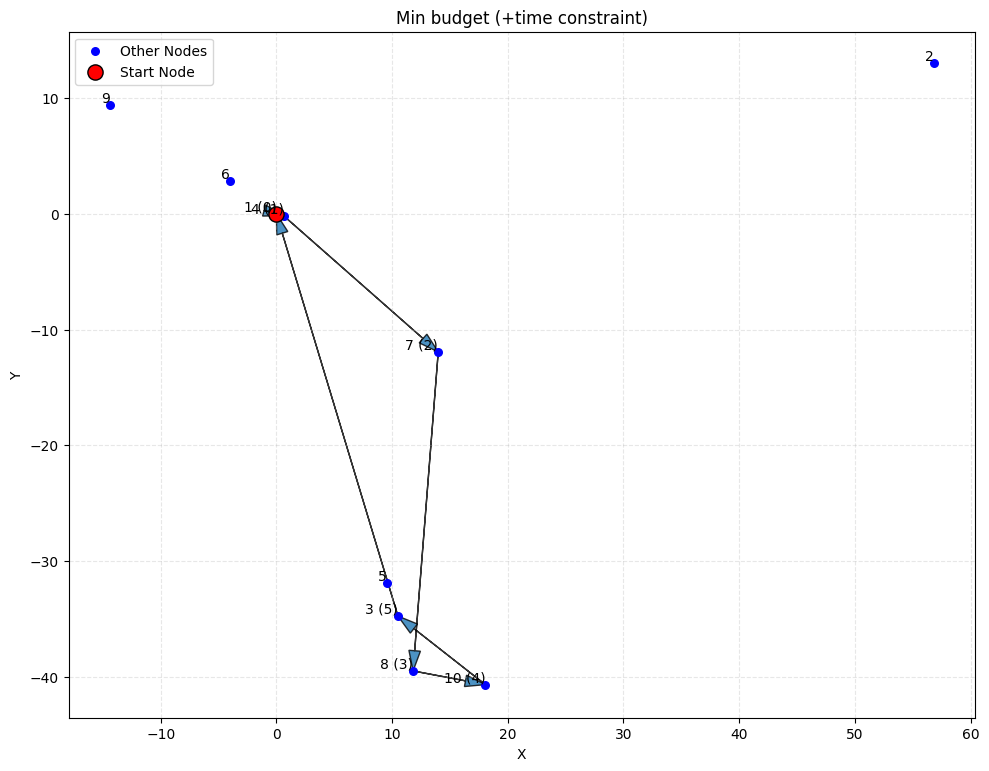

In [3]:
runner.apply_min_budget(time_max=time_max, dist_max=dist_max)

results, ok = runner.solve(SOLVER=SOLVER, NEOS_EMAIL=NEOS_EMAIL, tee=False)

if ok:
    runner.print_metrics()
    runner.extract_tour()
    print("Tour:", runner.tour)
    runner.plot(title="Min budget (+time constraint)")
else:
    print("Cannot construct tour with provided constraints")
    print(f"Check your limits:\n - Budget: {budget_max} UAH\n - Time: {time_max:.1f} Hours\n - Number of places: {k_value}")
    print("Try increasing your budget/time or reducing the number of points.")

WARNING (W1002): Setting Var 'u[1]' to a numeric value `0` outside the bounds
(1, 5).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002

Problem: 
- Lower bound: -.inf
  Upper bound: .inf
  Number of objectives: 1
  Number of constraints: 0
  Number of variables: 199
  Sense: unknown
Solver: 
- Status: ok
  Message: CPLEX 22.1.2\x3a optimal solution; objective 574.93; 188 simplex iterations
  Termination condition: optimal
  Id: 0
Solution: 
- number of solutions: 0
  number of solutions displayed: 0

Objective = 574.9300000000001
Total distance = 108.537 km
Total budget   = 13036.9535 UAH
  - Locations: 12440.00 UAH
  - Fuel:      596.95 UAH
Total time     = 574.9300000000001 minutes
Tour: [1, 6, 7, 3, 5, 4, 1]


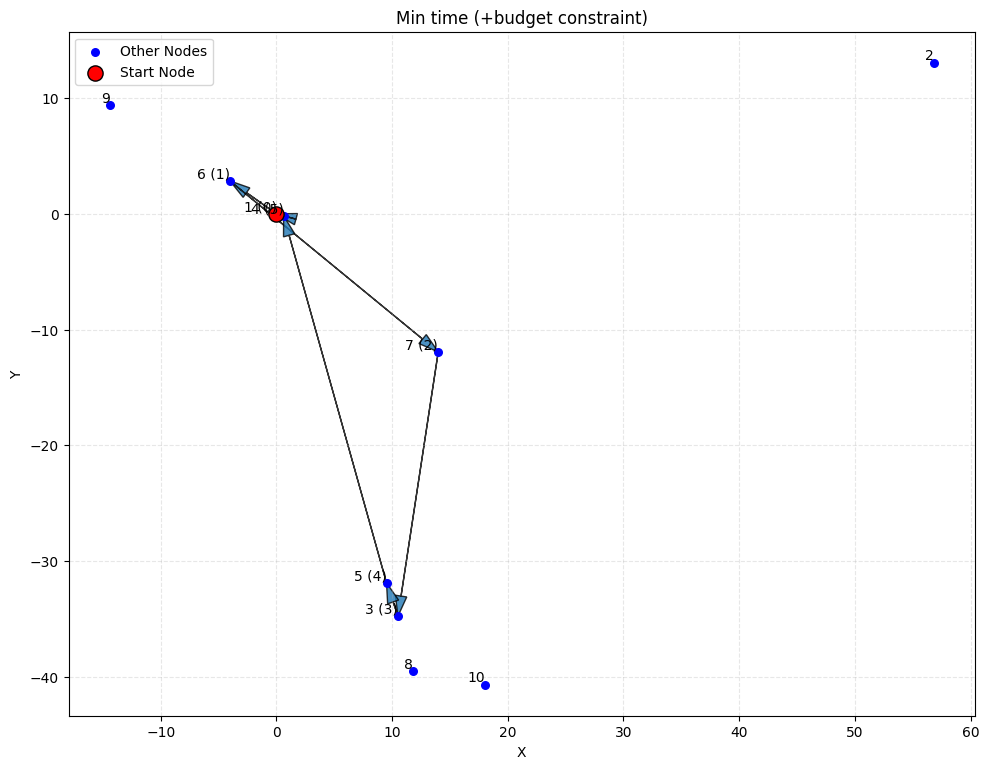

In [6]:
runner.apply_min_time(budget_max=budget_max, dist_max=dist_max)

results, ok = runner.solve(SOLVER=SOLVER, NEOS_EMAIL=NEOS_EMAIL, tee=False)

if ok:
    runner.print_metrics()
    runner.extract_tour()
    print("Tour:", runner.tour)
    runner.plot(title="Min time (+budget constraint)")
else:
    print("Cannot construct tour with provided constraints")
    print(f"Check your limits:\n - Budget: {budget_max} UAH\n - Time: {time_max:.1f} Hours\n - Number of places: {k_value}")
    print("Try increasing your budget/time or reducing the number of points.")